In [1]:
# Import required libraries and set random seeds for reproducibility

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math
import os
import random

In [3]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
# Read the CSV file into a pandas DataFrame and parse dates

In [6]:
df = pd.read_csv('monthly_milk_production.csv', parse_dates=['Date'], index_col='Date')
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [7]:
# Check dataframe shape, types, and missing values

In [8]:
print(df.shape)
print(df.info())
print(df.isna().sum())

(168, 1)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB
None
Production    0
dtype: int64


In [9]:
# View descriptive statistics to detect outliers or odd values

In [10]:
print(df.describe())

       Production
count  168.000000
mean   754.708333
std    102.204524
min    553.000000
25%    677.750000
50%    761.000000
75%    824.500000
max    969.000000


In [11]:
# Visualize the entire time series to inspect trend and seasonality

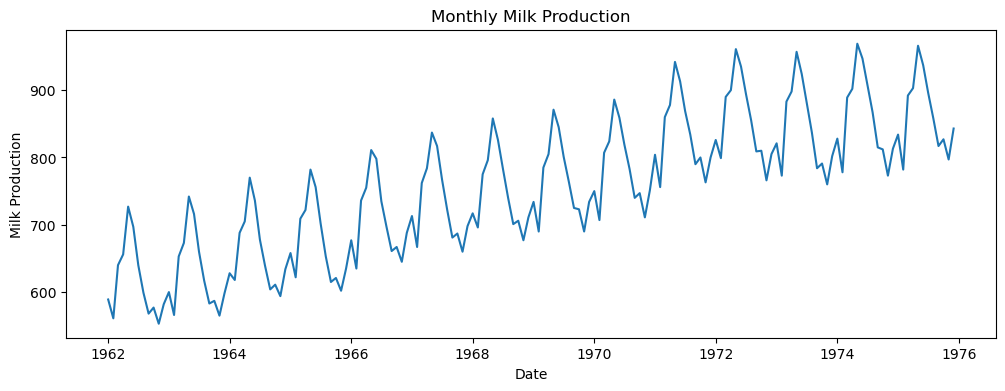

In [12]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df.iloc[:,0])
plt.title('Monthly Milk Production')
plt.ylabel('Milk Production')
plt.xlabel('Date')
plt.show()

In [13]:
# Decompose time series into trend, seasonal, and residual components

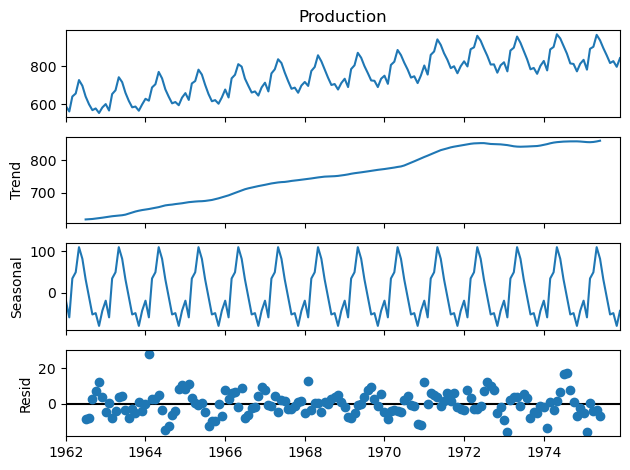

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose
res = seasonal_decompose(df.iloc[:,0], model='additive', period=12)
res.plot()
plt.show()

In [15]:
# Run Augmented Dickey-Fuller test to check stationarity

In [16]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(df.iloc[:,0])
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])

ADF Statistic: -1.3038115874221312
p-value: 0.6274267086030308


In [17]:
# Scale values to [0,1] which helps neural network training

In [18]:
scaler = MinMaxScaler()
series = df.iloc[:,0].values.reshape(-1,1)
scaled = scaler.fit_transform(series)

In [19]:
# Function to create input-output pairs for sequence models

In [22]:
def create_sequences(data, window_size=12):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

In [23]:
# Build sequences and split into training, validation and test sets (70/15/15)

In [26]:
WINDOW = 12
X, y = create_sequences(scaled, WINDOW)
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)
X_train = X[:train_size]
y_train = y[:train_size]
X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]
X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

In [27]:
# Reshape for RNN/LSTM/GRU -> (samples, timesteps, features)

In [28]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
print('Train:', X_train.shape, y_train.shape)
print('Val:', X_val.shape, y_val.shape)
print('Test:', X_test.shape, y_test.shape)

Train: (109, 12, 1) (109, 1)
Val: (23, 12, 1) (23, 1)
Test: (24, 12, 1) (24, 1)


In [29]:
# Create function to build RNN/LSTM/GRU models with flexible parameters

In [48]:
from tensorflow.keras import Input
def build_model(model_type='LSTM', units=50, dropout=0.0, input_shape=(WINDOW,1)):
    model = Sequential()
    model.add(Input(shape=input_shape))
    if model_type == 'RNN':
        model.add(SimpleRNN(units, input_shape=input_shape))
    elif model_type == 'LSTM':
        model.add(LSTM(units, input_shape=input_shape))
    elif model_type == 'GRU':
        model.add(GRU(units, input_shape=input_shape))
    else:
        raise ValueError('model_type must be RNN, LSTM, or GRU')
    if dropout>0:
        model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

In [49]:
# Set early stopping and model checkpointing to avoid overfitting

In [50]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint_path = 'best_model.h5'
mc = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True)

In [51]:
# Train a baseline LSTM model to get initial performance numbers

In [61]:
import warnings
warnings.filterwarnings('ignore')
lstm = build_model('LSTM', units=50, dropout=0.1)
history_lstm = lstm.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val,y_val), callbacks=[es,mc], verbose=2)

Epoch 1/100
7/7 - 2s - 285ms/step - loss: 0.1062 - val_loss: 0.0953
Epoch 2/100
7/7 - 0s - 64ms/step - loss: 0.0327 - val_loss: 0.0324
Epoch 3/100
7/7 - 0s - 46ms/step - loss: 0.0339 - val_loss: 0.0294
Epoch 4/100
7/7 - 0s - 40ms/step - loss: 0.0257 - val_loss: 0.0334
Epoch 5/100
7/7 - 0s - 31ms/step - loss: 0.0258 - val_loss: 0.0366
Epoch 6/100
7/7 - 0s - 49ms/step - loss: 0.0255 - val_loss: 0.0277
Epoch 7/100
7/7 - 0s - 48ms/step - loss: 0.0261 - val_loss: 0.0255
Epoch 8/100
7/7 - 0s - 49ms/step - loss: 0.0245 - val_loss: 0.0269
Epoch 9/100
7/7 - 0s - 48ms/step - loss: 0.0260 - val_loss: 0.0273
Epoch 10/100
7/7 - 0s - 15ms/step - loss: 0.0240 - val_loss: 0.0259


In [62]:
# Visualize training and validation loss curves

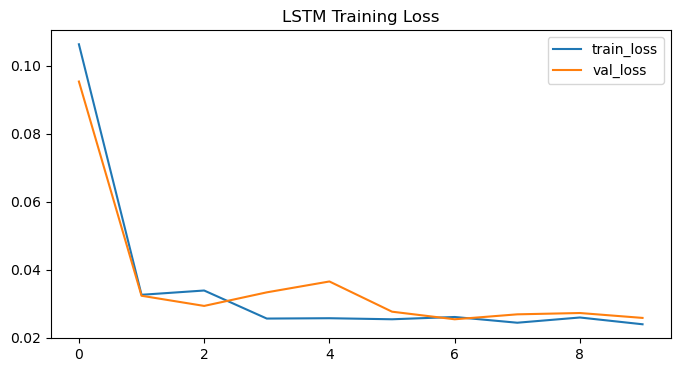

In [63]:
plt.figure(figsize=(8,4))
plt.plot(history_lstm.history['loss'], label='train_loss')
plt.plot(history_lstm.history['val_loss'], label='val_loss')
plt.legend()
plt.title('LSTM Training Loss')
plt.show()

In [64]:
# Helper to convert scaled predictions back to original scale and compute metrics

In [65]:
def evaluate_model(model, X, y_true, scaler):
    y_pred_scaled = model.predict(X)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true_orig = scaler.inverse_transform(y_true)
    rmse = math.sqrt(mean_squared_error(y_true_orig, y_pred))
    mae = mean_absolute_error(y_true_orig, y_pred)
    mape = np.mean(np.abs((y_true_orig - y_pred) / y_true_orig)) * 100
    return y_pred.flatten(), y_true_orig.flatten(), rmse, mae, mape

In [66]:
# Get test predictions and performance metrics for the LSTM model

In [67]:
lstm_preds, lstm_true, lstm_rmse, lstm_mae, lstm_mape = evaluate_model(lstm, X_test, y_test, scaler)
print('LSTM RMSE:', lstm_rmse, 'MAE:', lstm_mae, 'MAPE:', lstm_mape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
LSTM RMSE: 134.21607623858114 MAE: 118.89322662353516 MAPE: 13.398202324257834


In [68]:
# Train SimpleRNN and GRU models with same hyperparameters for fair comparison

In [70]:
rnn = build_model('RNN', units=50, dropout=0.1)
gru = build_model('GRU', units=50, dropout=0.1)
history_rnn = rnn.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val,y_val), callbacks=[EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)], verbose=2)
history_gru = gru.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val,y_val), callbacks=[EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)], verbose=2)

Epoch 1/100
7/7 - 2s - 248ms/step - loss: 0.0727 - val_loss: 0.0292
Epoch 2/100
7/7 - 0s - 62ms/step - loss: 0.0248 - val_loss: 0.0276
Epoch 3/100
7/7 - 0s - 48ms/step - loss: 0.0127 - val_loss: 0.0087
Epoch 4/100
7/7 - 0s - 24ms/step - loss: 0.0096 - val_loss: 0.0144
Epoch 5/100
7/7 - 0s - 22ms/step - loss: 0.0073 - val_loss: 0.0054
Epoch 6/100
7/7 - 0s - 46ms/step - loss: 0.0064 - val_loss: 0.0064
Epoch 7/100
7/7 - 0s - 25ms/step - loss: 0.0040 - val_loss: 0.0054
Epoch 8/100
7/7 - 0s - 39ms/step - loss: 0.0045 - val_loss: 0.0049
Epoch 9/100
7/7 - 0s - 34ms/step - loss: 0.0062 - val_loss: 0.0044
Epoch 10/100
7/7 - 0s - 49ms/step - loss: 0.0059 - val_loss: 0.0063
Epoch 11/100
7/7 - 0s - 49ms/step - loss: 0.0055 - val_loss: 0.0042
Epoch 12/100
7/7 - 0s - 47ms/step - loss: 0.0048 - val_loss: 0.0040
Epoch 13/100
7/7 - 0s - 49ms/step - loss: 0.0037 - val_loss: 0.0037
Epoch 14/100
7/7 - 0s - 49ms/step - loss: 0.0036 - val_loss: 0.0032
Epoch 15/100
7/7 - 0s - 42ms/step - loss: 0.0039 - val_l

In [73]:
# Compute predictions and metrics for RNN and GRU models

In [74]:
rnn_preds, rnn_true, rnn_rmse, rnn_mae, rnn_mape = evaluate_model(rnn, X_test, y_test, scaler)
gru_preds, gru_true, gru_rmse, gru_mae, gru_mape = evaluate_model(gru, X_test, y_test, scaler)
print('RNN RMSE:', rnn_rmse, 'MAE:', rnn_mae, 'MAPE:', rnn_mape)
print('GRU RMSE:', gru_rmse, 'MAE:', gru_mae, 'MAPE:', gru_mape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
RNN RMSE: 17.760868575290587 MAE: 14.753311157226554 MAPE: 1.681944170211504
GRU RMSE: 59.376664940741435 MAE: 51.06333669026693 MAPE: 5.91098607819149


In [75]:
# Plot test set actuals and predictions for comparison (choose model with best RMSE)

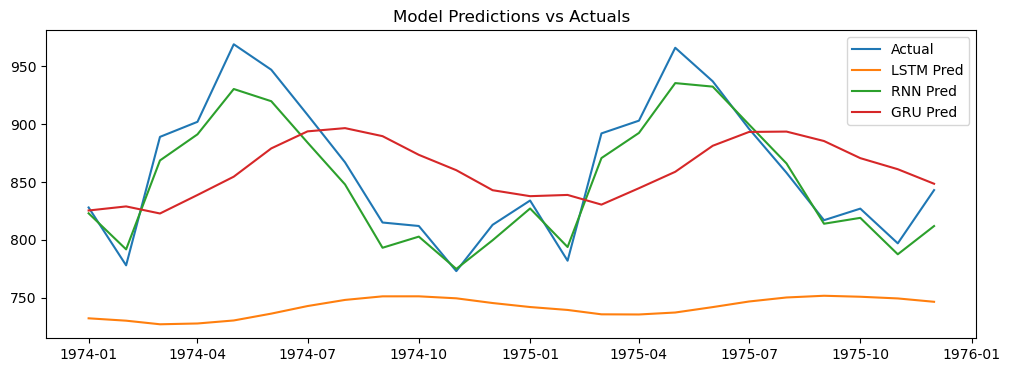

In [76]:
plt.figure(figsize=(12,4))
plt.plot(df.index[-len(lstm_true):], lstm_true, label='Actual')
plt.plot(df.index[-len(lstm_preds):], lstm_preds, label='LSTM Pred')
plt.plot(df.index[-len(rnn_preds):], rnn_preds, label='RNN Pred')
plt.plot(df.index[-len(gru_preds):], gru_preds, label='GRU Pred')
plt.legend()
plt.title('Model Predictions vs Actuals')
plt.show()

In [77]:
# Use the best model to iteratively forecast the next 12 months

In [78]:
model_scores = {'LSTM': lstm_rmse, 'RNN': rnn_rmse, 'GRU': gru_rmse}
best_name = min(model_scores, key=model_scores.get)
best_model = {'LSTM': lstm, 'RNN': rnn, 'GRU': gru}[best_name]
print('Best model:', best_name)
last_window = scaled[-WINDOW:].reshape(1, WINDOW, 1)
forecast_scaled = []
for _ in range(12):
    next_pred = best_model.predict(last_window)
    forecast_scaled.append(next_pred.flatten()[0])
    last_window = np.roll(last_window, -1)
    last_window[0, -1, 0] = next_pred
forecast_scaled = np.array(forecast_scaled).reshape(-1,1)
forecast = scaler.inverse_transform(forecast_scaled).flatten()

Best model: RNN


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [79]:
# Prepare forecast dates
last_date = df.index.max()
forecast_index = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=12, freq='MS')
forecast_series = pd.Series(forecast, index=forecast_index)

In [80]:
# Visualize historical series together with 12-month forecast

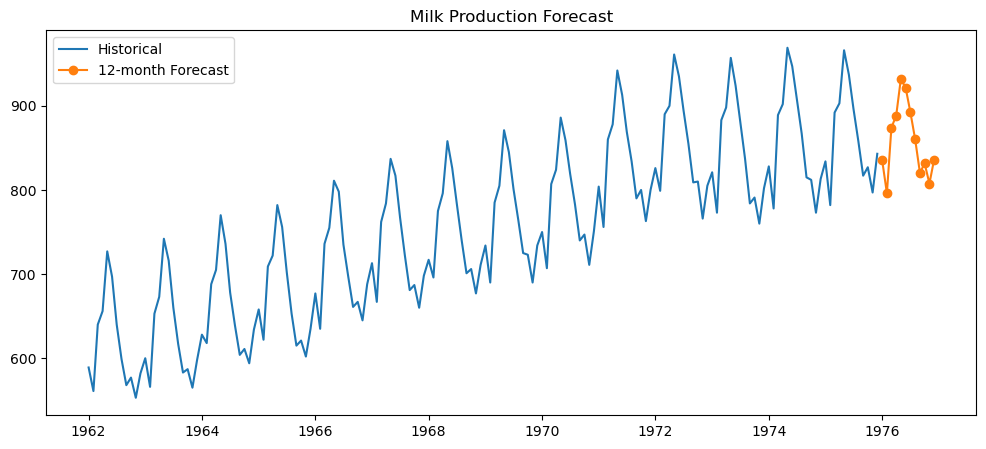

In [81]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df.iloc[:,0], label='Historical')
plt.plot(forecast_series.index, forecast_series.values, label='12-month Forecast', marker='o')
plt.title('Milk Production Forecast')
plt.legend()
plt.show()

In [82]:
# Save the best model and the scaler

In [83]:
best_model.save(f'best_model_{best_name}.h5')
import joblib
joblib.dump(scaler, 'scaler.gz')

['scaler.gz']

In [84]:
# In this assignment, we analyzed monthly milk production data and developed deep learning models to forecast future production. 
# We performed exploratory data analysis to understand trends and seasonality, prepared the data by creating time-windowed sequences, 
# and built three forecasting models—RNN, LSTM, and GRU. Each model was trained and evaluated using metrics such as RMSE, MAE, and MAPE, 
# and their predictions were compared against actual values. 
# Finally, we forecasted future milk production and visualized the results to provide insights that can help the dairy business 
# improve planning, inventory management, and decision-making.